Dataset loaded successfully
Shape: (7043, 21)

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

 

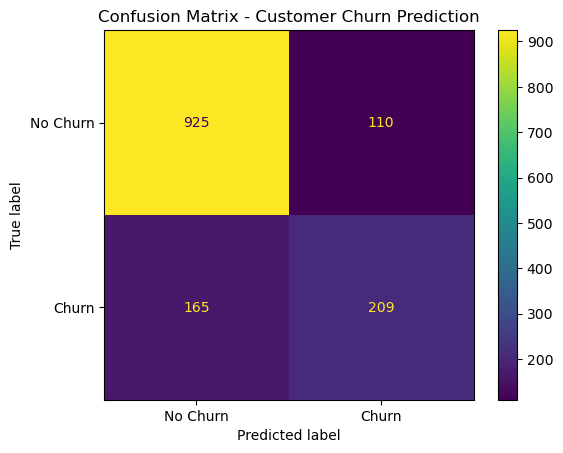


Pipeline saved successfully as:
customer_churn_pipeline.joblib

Sample Customer:
    gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
437   Male              0     Yes        Yes      72          Yes   

    MultipleLines InternetService OnlineSecurity OnlineBackup  \
437           Yes     Fiber optic            Yes          Yes   

    DeviceProtection TechSupport StreamingTV StreamingMovies  Contract  \
437              Yes         Yes         Yes             Yes  Two year   

    PaperlessBilling            PaymentMethod  MonthlyCharges  TotalCharges  
437              Yes  Credit card (automatic)          114.05        8468.2  

Sample Prediction:
Customer is NOT likely to churn.
Churn Probability: 4.74 %

Reusable Function Output:
Prediction: No Churn
Probability: 4.74 %

Task Completed Successfully!
Preprocessing using Pipeline: Done
Scaling numeric features: Done
Encoding categorical features: Done
Logistic Regression trained: Done
Random Forest trained: Done
Gr

In [1]:
# ============================================================
# Task 2: End-to-End ML Pipeline with Scikit-learn Pipeline API
# Dataset: Telco Customer Churn
# Models: Logistic Regression + Random Forest
# Tuning: GridSearchCV
# Export: joblib
# ============================================================

import sys
import subprocess
import os
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# 1. Install Required Packages
# ============================================================

packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "sklearn": "scikit-learn",
    "joblib": "joblib",
    "matplotlib": "matplotlib"
}

for import_name, install_name in packages.items():
    try:
        __import__(import_name)
    except ImportError:
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            install_name
        ])

# ============================================================
# 2. Import Libraries
# ============================================================

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# ============================================================
# 3. Load Dataset
# ============================================================

FILE_PATH = r"C:\Users\bilal\Downloads\Telco-Customer-Churn.csv"

if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(
        "Dataset file nahi mili. File ka naam check karo: "
        "C:\\Users\\bilal\\Downloads\\Telco-Customer-Churn.csv"
    )

df = pd.read_csv(FILE_PATH)

print("Dataset loaded successfully")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nColumns:")
print(df.columns.tolist())

# ============================================================
# 4. Basic Data Cleaning
# ============================================================

# customerID model ke liye useful nahi hota
if "customerID" in df.columns:
    df = df.drop("customerID", axis=1)

# TotalCharges usually text/object hota hai, isko numeric banana zaroori hai
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Target column check
if "Churn" not in df.columns:
    raise ValueError("Target column 'Churn' dataset mein nahi mila.")

# Churn ko numeric target mein convert karo
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

# Target missing rows remove
df = df.dropna(subset=["Churn"])

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Distribution:")
print(df["Churn"].value_counts())

# ============================================================
# 5. Split Features and Target
# ============================================================

X = df.drop("Churn", axis=1)
y = df["Churn"]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("\nNumeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

# ============================================================
# 6. Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

# ============================================================
# 7. Preprocessing Pipelines
# ============================================================

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", encoder)
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

# ============================================================
# 8. Complete ML Pipeline
# ============================================================

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

# ============================================================
# 9. GridSearchCV Parameters
# ============================================================

param_grid = [
    {
        "model": [LogisticRegression(max_iter=1000)],
        "model__C": [0.01, 0.1, 1, 10],
        "model__solver": ["liblinear"]
    },
    {
        "model": [RandomForestClassifier(random_state=42)],
        "model__n_estimators": [100, 200],
        "model__max_depth": [5, 10, None],
        "model__min_samples_split": [2, 5]
    }
]

# ============================================================
# 10. Train Models with GridSearchCV
# ============================================================

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=2
)

print("\nTraining started with GridSearchCV...")
grid_search.fit(X_train, y_train)
print("Training completed.")

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation F1 Score:")
print(round(grid_search.best_score_, 4))

best_model = grid_search.best_estimator_

# ============================================================
# 11. Evaluate Best Model
# ============================================================

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("\nTest Evaluation Results")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

# ============================================================
# 12. Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

display.plot()
plt.title("Confusion Matrix - Customer Churn Prediction")
plt.show()

# ============================================================
# 13. Export Complete Pipeline Using joblib
# ============================================================

MODEL_PATH = "customer_churn_pipeline.joblib"

joblib.dump(best_model, MODEL_PATH)

print("\nPipeline saved successfully as:")
print(MODEL_PATH)

# ============================================================
# 14. Load Saved Pipeline and Test
# ============================================================

loaded_pipeline = joblib.load(MODEL_PATH)

sample_customer = X_test.iloc[[0]]

sample_prediction = loaded_pipeline.predict(sample_customer)[0]
sample_probability = loaded_pipeline.predict_proba(sample_customer)[0][1]

print("\nSample Customer:")
print(sample_customer)

print("\nSample Prediction:")

if sample_prediction == 1:
    print("Customer is likely to CHURN.")
else:
    print("Customer is NOT likely to churn.")

print("Churn Probability:", round(sample_probability * 100, 2), "%")

# ============================================================
# 15. Reusable Prediction Function
# ============================================================

def predict_customer_churn(customer_data):
    """
    customer_data must be a pandas DataFrame
    with the same feature columns as training data.
    """

    model = joblib.load("customer_churn_pipeline.joblib")

    prediction = model.predict(customer_data)[0]
    probability = model.predict_proba(customer_data)[0][1]

    if prediction == 1:
        result = "Churn"
    else:
        result = "No Churn"

    return result, probability

result, probability = predict_customer_churn(sample_customer)

print("\nReusable Function Output:")
print("Prediction:", result)
print("Probability:", round(probability * 100, 2), "%")

# ============================================================
# 16. Final Summary
# ============================================================

print("\nTask Completed Successfully!")
print("Preprocessing using Pipeline: Done")
print("Scaling numeric features: Done")
print("Encoding categorical features: Done")
print("Logistic Regression trained: Done")
print("Random Forest trained: Done")
print("GridSearchCV tuning: Done")
print("Pipeline exported using joblib: Done")